# Task B-1: Input Data Description and Exploration
**Project:** Torterm — AI Home Renovation Chatbot  
**Course:** 01219462 Software Engineering for AI-Enabled System  
**Dataset:** HomePro exterior renovation products (scraped catalog)

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load Dataset

In [2]:
DATA_DIR = '../data'
files = ['homepro_exterior.json', 'con.json', 'dow.json', 'flo.json', 'out.json', 'pai.json']

records = []
for f in files:
    path = os.path.join(DATA_DIR, f)
    with open(path, encoding='utf-8') as fp:
        records.extend(json.load(fp))

df = pd.DataFrame(records)
print(f'Total records: {len(df)}')
df.head(3)

Total records: 100


,url,category,name,price,original_price,sku,brand,images,description,specs
0,https://www.homepro.co.th/p/1296258,ประตูและหน้าต่าง,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,359,409,1296258,ร็อควูล,[https://statice.homepro.co.th/homepro/ART_IMA...,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,xxxx\n\t\t\t\t\t\n\t\t\t\t\t\n\t\t\t\t\t\tแบรน...
1,https://www.homepro.co.th/p/1301618,ประตูและหน้าต่าง,กลอนดิจิตอล HILOCK HL-631W สีขาว,5990,14900,1301618,HILOCK,[https://statice.homepro.co.th/homepro/ART_IMA...,กลอนดิจิตอล HILOCK HL-631W สีขาว\n\nเพิ่มความป...,xxxx\n\t\t\t\t\t\n\t\t\t\t\t\n\t\t\t\t\t\tแบรน...
2,https://www.homepro.co.th/p/888226900003,ประตูและหน้าต่าง,กลอนดิจิตอล LOCKHOME รุ่น MOTION PRO FG ระบบสแ...,6390,7990,888226900003,Lockhome,[https://static.homepro.co.th/seller/2269/hp-r...,กลอนดิจิตอล LOCKHOME รุ่น MOTION PRO FG ระบบสแ...,xxxx\n\t\t\t\t\t\n\t\t\t\t\t\n\t\t\t\t\t\tแบรน...


## 2. Data Types and Schema

In [3]:
print('=== Column types ===')
print(df.dtypes)
print('\n=== Missing values ===')
print(df.isnull().sum())
print('\n=== Shape ===')
print(df.shape)

=== Column types ===
url               object
category          object
name              object
price             object
original_price    object
sku               object
brand             object
images            object
description       object
specs             object
dtype: object

=== Missing values ===
url                0
category           0
name               0
price             12
original_price     0
sku                0
brand              0
images             0
description        0
specs              0
dtype: int64

=== Shape ===
(100, 10)


## 3. Category Distribution

category_en
Door & Window            20
Floor & Wall             20
Construction Material    20
Outdoor Furniture        20
Paint & Tools            20
Name: count, dtype: int64


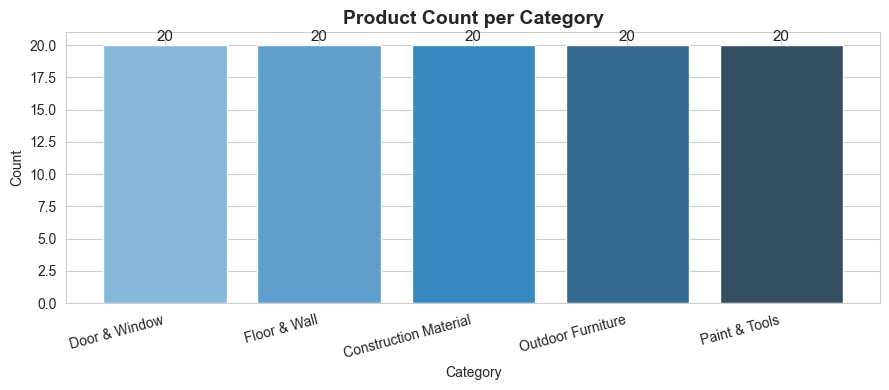


Dataset is perfectly balanced — 20 products per category.


In [4]:
# Map Thai category names to English for readability
cat_map = {
    'ประตูและหน้าต่าง': 'Door & Window',
    'วัสดุปูพื้นและผนัง': 'Floor & Wall',
    'วัสดุก่อสร้าง': 'Construction Material',
    'เฟอร์นิเจอร์นอกบ้านและสวน': 'Outdoor Furniture',
    'สีและอุปกรณ์ทาสี': 'Paint & Tools'
}
df['category_en'] = df['category'].map(cat_map)

cat_counts = df['category_en'].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cat_counts.index, cat_counts.values, color=sns.color_palette('Blues_d', len(cat_counts)))
ax.set_title('Product Count per Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('B1_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nDataset is perfectly balanced — 20 products per category.')

## 4. Price Distribution

=== Price Statistics (THB) ===
count       88.0
mean      4359.0
std       7785.0
min         55.0
25%        359.0
50%       1794.0
75%       4531.0
max      32999.0
Name: price_num, dtype: float64


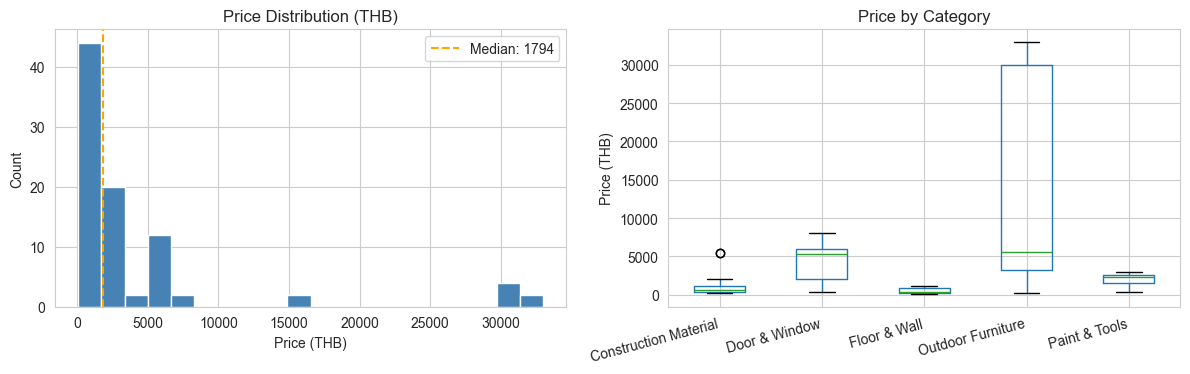

In [5]:
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')
df['original_price_num'] = pd.to_numeric(df['original_price'], errors='coerce')
df['discount_pct'] = ((df['original_price_num'] - df['price_num']) / df['original_price_num'] * 100).round(1)

print('=== Price Statistics (THB) ===')
print(df['price_num'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['price_num'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (THB)')
axes[0].set_xlabel('Price (THB)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price_num'].median(), color='orange', linestyle='--', label=f"Median: {df['price_num'].median():.0f}")
axes[0].legend()

# By category
df.boxplot(column='price_num', by='category_en', ax=axes[1])
axes[1].set_title('Price by Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price (THB)')
plt.suptitle('')
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('B1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Text Features: Name and Description Length

=== Name Length ===
count    100.0
mean      57.0
std       16.0
min       32.0
25%       45.0
50%       56.0
75%       71.0
max       86.0
Name: name_len, dtype: float64

=== Description Length ===
count     100.0
mean     1416.0
std       346.0
min       619.0
25%      1213.0
50%      1342.0
75%      1592.0
max      2000.0
Name: desc_len, dtype: float64


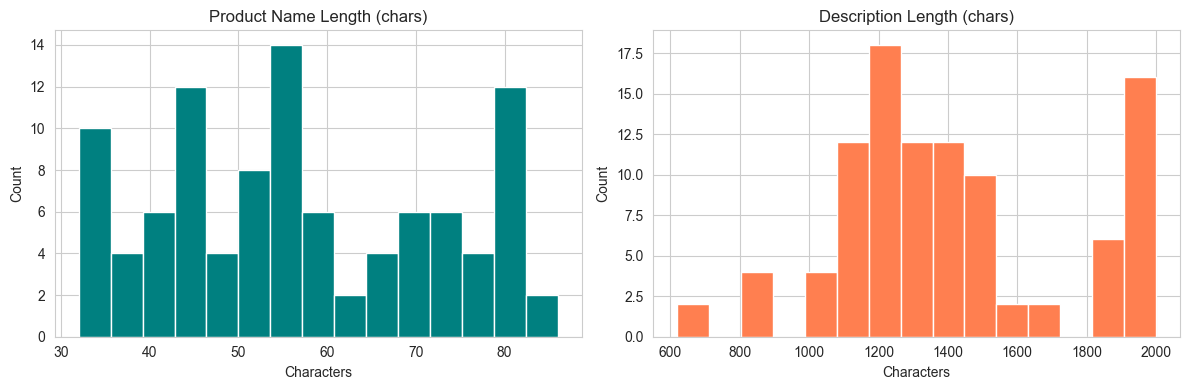

In [6]:
df['name_len'] = df['name'].str.len()
df['desc_len'] = df['description'].fillna('').str.len()

print('=== Name Length ===')
print(df['name_len'].describe().round(0))
print('\n=== Description Length ===')
print(df['desc_len'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['name_len'], bins=15, color='teal', edgecolor='white')
axes[0].set_title('Product Name Length (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(df['desc_len'], bins=15, color='coral', edgecolor='white')
axes[1].set_title('Description Length (chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('B1_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Brand Analysis

Unique brands: 24
brand
TOA         20
SPRING      14
ร็อควูล      8
TARA         6
CROBERN      6
BEGER        6
SIKA         4
YALE         4
ECO-DOOR     2
จระเข้       2
BENETTA      2
Lockhome     2
LetPot       2
COCOLUXE     2
SCG          2
Name: count, dtype: int64


/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/f5h66w5d1j75w1y00fn7gbtm0000gn/T/ipykernel_62035/1880284414.py:9:

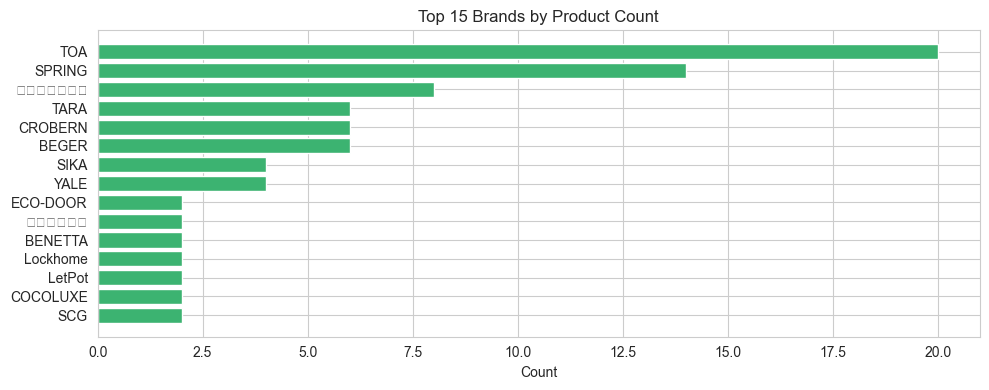

In [7]:
brand_counts = df['brand'].value_counts().head(15)
print(f'Unique brands: {df["brand"].nunique()}')
print(brand_counts)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(brand_counts.index[::-1], brand_counts.values[::-1], color='mediumseagreen')
ax.set_title('Top 15 Brands by Product Count')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('B1_brand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Discount Analysis

In [8]:
discounted = df[df['discount_pct'] > 0]
print(f'Products with discount: {len(discounted)} / {len(df)} ({len(discounted)/len(df)*100:.0f}%)')
print(f'Average discount: {discounted["discount_pct"].mean():.1f}%')
print(f'Max discount: {discounted["discount_pct"].max():.1f}%')

disc_by_cat = discounted.groupby('category_en')['discount_pct'].mean().sort_values(ascending=False)
print('\nAverage discount by category:')
print(disc_by_cat.round(1))

Products with discount: 88 / 100 (88%)
Average discount: 27.0%
Max discount: 66.8%

Average discount by category:
category_en
Outdoor Furniture        33.3
Door & Window            28.4
Construction Material    28.2
Floor & Wall             23.8
Paint & Tools            20.8
Name: discount_pct, dtype: float64


## 8. Sample Records

In [9]:
display_cols = ['category_en', 'name', 'brand', 'price_num', 'discount_pct']
print('=== Sample records (one per category) ===')
df.groupby('category_en').first()[display_cols[1:]].reset_index().rename(columns={'category_en':'Category','name':'Name','brand':'Brand','price_num':'Price (THB)','discount_pct':'Discount %'})

=== Sample records (one per category) ===


,Category,Name,Brand,Price (THB),Discount %
0,Construction Material,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,ร็อควูล,359.0,12.2
1,Door & Window,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,ร็อควูล,359.0,12.2
2,Floor & Wall,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,ร็อควูล,359.0,12.2
3,Outdoor Furniture,ชิงช้า 4 ที่นั่ง COCOLUXE รุ่น SWAY WARM มาพร้...,COCOLUXE,4275.0,10.0
4,Paint & Tools,ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หน...,ร็อควูล,359.0,12.2


## 9. Sensitive Features and Fairness Considerations

This dataset contains product catalog data — no personal/user data is involved.  
Sensitive features to consider:
- **Price range**: High-price products dominate some categories → may bias recommendations toward expensive items
- **Brand representation**: Some brands appear more frequently → model may over-recommend popular brands
- **Language**: All text is Thai → model must handle Thai tokenization correctly

Mitigation: Use TF-IDF character n-grams (handles Thai without word boundaries) and evaluate per-category performance to ensure no category is systematically misclassified.

## 10. Summary

| Feature | Details |
|---|---|
| Total products | 100 |
| Categories | 5 (perfectly balanced — 20 each) |
| Price range | 55 – 32,999 THB |
| Median price | ~1,500 THB |
| Unique brands | varies by file |
| Text fields | name (Thai), description (Thai) |
| Missing values | None in key fields |
| Class imbalance | None — ideal for classification |

**Data collection strategy:** Products were scraped from HomePro Thailand using Playwright. Each category page was scraped for product name, price, brand, description, and images. The data represents the publicly available product catalog — no personal or sensitive user data is included.